# TSLA Liquidity Zone Analysis

This notebook performs a full **liquidity zone and sweep analysis** on TSLA across two timeframes:

| Timeframe | Interval | Source | Date Range |
|---|---|---|---|
| HTF (High Timeframe) | Daily | Yahoo Finance (yfinance) | 2021-01-04 → 2024-09-30 |
| LTF (Low Timeframe) | Hourly | Local CSV (`data/raw/TSLA_60min.csv`) | 2021-01-04 → 2024-09-30 |

> **Note:** Yahoo Finance only retains ~730 days of hourly data, so the LTF series is loaded from a local file. Daily data covers the full requested range.

---

## Notebook Structure

| Part | Description |
|---|---|
| **Part 1 — Setup & Data Loading** | Imports, parameters, download/read data, save CSVs, sanity check |
| **Part 2 — Core Analytical Functions** | Define ATR, SMA, pivot detection, zone builder, sweep detector, tagger, and chart functions |
| **Part 3 — Daily (HTF) Analysis** | Build and visualise liquidity zones on the daily timeframe |
| **Part 4 — Hourly (LTF) Analysis** | Build and visualise liquidity zones on the hourly timeframe |
| **Part 5 — Liquidity Sweep Detection** | Detect buy/sell-side sweeps and cross-reference with zones |
| **Part 6 — Export Results** | Write all outputs to Excel (one workbook per timeframe) |


## Part 1 — Setup & Data Loading

Configure the ticker and date range, download **daily** OHLCV data from Yahoo Finance, and read **hourly** data from the local CSV. Both datasets are saved to `data/raw/` with date-stamped filenames, then reloaded and verified.


In [ ]:
# ---------------------------------------------------------------------------
# Imports & parameters
# ---------------------------------------------------------------------------
import yfinance as yf
import pandas as pd
from datetime import date, timedelta
from pathlib import Path

TICKER     = "TSLA"
START_DATE = date(2021, 1, 4)
END_DATE   = date(2024, 9, 30)

# Output directory (created automatically if missing)
OUT_DIR = Path("data/raw")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Ticker     : {TICKER}")
print(f"Start date : {START_DATE}")
print(f"End date   : {END_DATE}")
print(f"Output dir : {OUT_DIR.resolve()}")


Ticker     : TSLA
Start date : 2021-01-04
End date   : 2024-09-30
Output dir : C:\Users\rickc\OneDrive\文件\CUHK\RMS6007 Risk and Finance\Group Porject\RMSC6007_Liquidity-Zones\data\raw


In [ ]:
# ---------------------------------------------------------------------------
# Download daily data (HTF)
# ---------------------------------------------------------------------------
print("Downloading daily (HTF) data...")

df_daily = yf.download(
    tickers=TICKER,
    start=START_DATE.isoformat(),
    end=(END_DATE + timedelta(days=1)).isoformat(),
    interval="1d",
    auto_adjust=True,
    progress=False,
    multi_level_index=False,
)

df_daily.index.name = "Datetime"
print(f"Daily rows : {len(df_daily)}")
print(f"Date range : {df_daily.index[0].date()} -> {df_daily.index[-1].date()}")
df_daily.tail(3)


Daily rows : 941
Date range : 2021-01-04 -> 2024-09-30


,Close,High,Low,Open,Volume
Datetime,,,,,
2024-09-26,254.220001,261.750000,251.529999,260.600006,67142200
2024-09-27,260.459991,260.700012,254.119995,257.380005,70988100
2024-09-30,261.630005,264.859985,255.770004,259.040009,80705700


In [ ]:
# ---------------------------------------------------------------------------
# Read hourly data (LTF) from local CSV
# ---------------------------------------------------------------------------
CSV_PATH = Path("data/raw/TSLA_60min.csv")

print(f"Reading hourly (LTF) data from {CSV_PATH.resolve()} ...")

df_hourly = pd.read_csv(CSV_PATH, index_col=0, parse_dates=True)
df_hourly.index = pd.to_datetime(df_hourly.index, dayfirst=True)
df_hourly.index.name = "Datetime"
df_hourly.sort_index(inplace=True)

# Filter to the same date range as df_daily
df_hourly = df_hourly.loc[START_DATE.isoformat() : END_DATE.isoformat()]

if df_hourly.empty:
    raise RuntimeError(f"df_hourly is empty. Check that {CSV_PATH} exists and covers {START_DATE} – {END_DATE}.")

print(f"\nHourly rows : {len(df_hourly)}")
print(f"Date range  : {df_hourly.index.min()} -> {df_hourly.index.max()}")
df_hourly.head(5)


Reading hourly (LTF) data from C:\Users\rickc\OneDrive\文件\CUHK\RMS6007 Risk and Finance\Group Porject\RMSC6007_Liquidity-Zones\data\raw\TSLA_60min.csv ...

Hourly rows : 6560
Date range  : 2021-01-04 14:00:00 -> 2024-09-30 20:00:00


,open,high,low,close,% change
Datetime,,,,,
2021-01-04 14:00:00,242.61,247.87,241.85,246.03,1.409670
2021-01-04 15:00:00,246.20,248.08,243.50,243.73,-1.003249
2021-01-04 16:00:00,243.73,245.58,242.75,243.60,-0.053338
2021-01-04 17:00:00,243.60,244.16,239.34,241.32,-0.935961
2021-01-04 18:00:00,241.32,245.48,241.10,244.38,1.268026


In [ ]:
# ---------------------------------------------------------------------------
# Save to CSV
# ---------------------------------------------------------------------------
# Use actual date ranges from the downloaded data (especially important for hourly)
daily_start  = df_daily.index.min().date()
daily_end    = df_daily.index.max().date()
hourly_start = df_hourly.index.min().date()
hourly_end   = df_hourly.index.max().date()

daily_path  = OUT_DIR / f"{TICKER}_daily_{daily_start}_{daily_end}.csv"
hourly_path = OUT_DIR / f"{TICKER}_hourly_{hourly_start}_{hourly_end}.csv"

df_daily.to_csv(daily_path)
df_hourly.to_csv(hourly_path)

print(f"Saved daily  -> {daily_path}")
print(f"Saved hourly -> {hourly_path}")


Saved daily  -> data\raw\TSLA_daily_2021-01-04_2024-09-30.csv
Saved hourly -> data\raw\TSLA_hourly_2021-01-04_2024-09-30.csv


In [ ]:
# ---------------------------------------------------------------------------
# Sanity check — reload and display shapes
# ---------------------------------------------------------------------------
reload_daily  = pd.read_csv(daily_path,  index_col="Datetime", parse_dates=True)
reload_hourly = pd.read_csv(hourly_path, index_col="Datetime", parse_dates=True)

print("=" * 45)
print(f"Daily  CSV shape  : {reload_daily.shape}")
print(f"Hourly CSV shape  : {reload_hourly.shape}")
print("=" * 45)
print("Daily columns : ",  reload_daily.columns.tolist())
print("Hourly columns: ",  reload_hourly.columns.tolist())
print("Daily head:")
display(reload_daily.head(3))
print("Hourly head:")
display(reload_hourly.head(3))


Daily  CSV shape  : (941, 5)
Hourly CSV shape  : (6560, 5)
Daily columns :  ['Close', 'High', 'Low', 'Open', 'Volume']
Hourly columns:  ['open', 'high', 'low', 'close', '% change']
Daily head:


,Close,High,Low,Open,Volume
Datetime,,,,,
2021-01-04,243.256668,248.163330,239.063339,239.820007,145914600
2021-01-05,245.036667,246.946671,239.733337,241.220001,96735600
2021-01-06,251.993332,258.000000,249.699997,252.830002,134100000


Hourly head:


,open,high,low,close,% change
Datetime,,,,,
2021-01-04 14:00:00,242.61,247.87,241.85,246.03,1.409670
2021-01-04 15:00:00,246.20,248.08,243.50,243.73,-1.003249
2021-01-04 16:00:00,243.73,245.58,242.75,243.60,-0.053338


## Part 2 — Core Analytical Functions

The cells below define all helper functions used in the analysis. **No computation runs here** — execute these cells once per session to make the functions available.

| Function | Purpose |
|---|---|
| `atr()` / `sma()` | Average True Range and Simple Moving Average |
| `detect_pivots()` | Identify structural pivot highs and lows using a symmetric window |
| `Zone` (dataclass) | Lightweight container storing a zone's price bounds and metadata |
| `build_liquidity_zones()` | Cluster volume-confirmed pivots into zones using ATR-based merging |
| `detect_liquidity_sweeps()` | Flag bars that spike through a prior pivot but close back inside it |
| `tag_sweeps_at_zones()` | Label sweeps that occur near a known liquidity zone |
| `plot_zones_matplotlib()` | Render price, pivots, and zones on a chart and save to disk |


In [ ]:
# ---------------------------------------------------------------------------
# Extra imports for Liquidity Zone analysis
# ---------------------------------------------------------------------------
from dataclasses import dataclass
from typing import List, Optional, Tuple
import os
import numpy as np


In [8]:
# ---------------------------------------------------------------------------
# Technical Utilities: ATR & SMA
# ---------------------------------------------------------------------------
def atr(df: pd.DataFrame, length: int = 14) -> pd.Series:
    """Average True Range (simple moving average of True Range)."""
    high = df["high"]
    low = df["low"]
    close = df["close"]
    prev_close = close.shift(1)
    tr = pd.concat([
        (high - low),
        (high - prev_close).abs(),
        (low - prev_close).abs()
    ], axis=1).max(axis=1)
    return tr.rolling(length, min_periods=length).mean()


def sma(series: pd.Series, length: int) -> pd.Series:
    return series.rolling(length, min_periods=length).mean()


In [9]:
# ---------------------------------------------------------------------------
# Pivot Detection (Symmetric)
# ---------------------------------------------------------------------------
def detect_pivots(
    df: pd.DataFrame,
    left: int = 10,
    right: int = 10,
    unique_in_window: bool = False,
) -> pd.DataFrame:
    """
    Detects pivot highs/lows:
      - Pivot High: high[i] is maximum within [i-left, i+right]
      - Pivot Low : low[i]  is minimum within [i-left, i+right]
    """
    out = df.copy()
    highs = out["high"].values
    lows = out["low"].values
    n = len(out)

    pivot_high = np.zeros(n, dtype=bool)
    pivot_low = np.zeros(n, dtype=bool)

    for i in range(left, n - right):
        wh = highs[i - left: i + right + 1]
        wl = lows[i - left: i + right + 1]

        is_ph = highs[i] == np.max(wh)
        is_pl = lows[i] == np.min(wl)

        if unique_in_window and is_ph:
            is_ph = (np.sum(wh == highs[i]) == 1)
        if unique_in_window and is_pl:
            is_pl = (np.sum(wl == lows[i]) == 1)

        pivot_high[i] = is_ph
        pivot_low[i] = is_pl

    out["pivot_high"] = pivot_high
    out["pivot_low"] = pivot_low
    out["pivot_high_level"] = np.where(pivot_high, out["high"].values, np.nan)
    out["pivot_low_level"] = np.where(pivot_low, out["low"].values, np.nan)
    return out


In [10]:
# ---------------------------------------------------------------------------
# Zone Data Structure
# ---------------------------------------------------------------------------
@dataclass
class Zone:
    top: float
    bottom: float
    touches: int
    first_idx: int
    last_idx: int
    first_time: pd.Timestamp
    last_time: pd.Timestamp

    @property
    def height(self) -> float:
        return float(self.top - self.bottom)


In [11]:
# ---------------------------------------------------------------------------
# Liquidity Zone Detector
# ---------------------------------------------------------------------------
def build_liquidity_zones(
    df: pd.DataFrame,
    pivot_left_right: int = 10,
    atr_len: int = 14,
    atr_merge_mult: float = 1.0,
    require_volume: bool = True,
    vol_len: int = 20,
    vol_mult: float = 1.2,
    min_touches: int = 2,
    unique_pivots: bool = False,
    use_both_high_low_pivots: bool = True,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    out = detect_pivots(df, left=pivot_left_right, right=pivot_left_right, unique_in_window=unique_pivots).copy()

    out["atr"] = atr(out, length=atr_len)
    if require_volume:
        out["vol_sma"] = sma(out["volume"], vol_len)
    else:
        out["vol_sma"] = np.nan

    pivots = []
    for i, row in enumerate(out.itertuples()):
        vol_ok = True
        if require_volume:
            if np.isnan(row.vol_sma):
                vol_ok = False
            else:
                vol_ok = (row.volume > row.vol_sma * vol_mult)
        if not vol_ok:
            continue
        if row.pivot_high:
            pivots.append((i, float(row.pivot_high_level)))
        if use_both_high_low_pivots and row.pivot_low:
            pivots.append((i, float(row.pivot_low_level)))

    zones: List[Zone] = []

    def best_merge_index(price: float, i: int) -> Optional[int]:
        if np.isnan(out.at[out.index[i], "atr"]):
            return None
        thr = float(out.at[out.index[i], "atr"]) * float(atr_merge_mult)
        max_merge_gap_days = 90
        best_idx = None
        best_height = np.inf
        for j, z in enumerate(zones):
            time_gap = (out.index[i] - z.last_time).days
            if time_gap > max_merge_gap_days:
                continue
            potential_top = max(z.top, price)
            potential_bot = min(z.bottom, price)
            new_h = potential_top - potential_bot
            if new_h <= thr and new_h < best_height:
                best_height = new_h
                best_idx = j
        return best_idx

    for i, p in pivots:
        j = best_merge_index(p, i)
        if j is None:
            zones.append(Zone(top=p, bottom=p, touches=1,
                              first_idx=i, last_idx=i,
                              first_time=out.index[i], last_time=out.index[i]))
        else:
            z = zones[j]
            z.top = max(z.top, p)
            z.bottom = min(z.bottom, p)
            z.touches += 1
            z.last_idx = i
            z.last_time = out.index[i]

    records = []
    for z in zones:
        if z.touches >= min_touches:
            records.append({
                "zone_id": f"{z.first_time.date()}_to_{z.last_time.date()}",
                "top": z.top, "bottom": z.bottom, "height": z.height,
                "touches": z.touches, "first_idx": z.first_idx, "last_idx": z.last_idx,
                "first_time": z.first_time, "last_time": z.last_time
            })

    _ZONE_COLS = ["zone_id", "top", "bottom", "height", "touches", "first_idx", "last_idx", "first_time", "last_time"]
    if not records:
        zones_df = pd.DataFrame(columns=_ZONE_COLS)
    else:
        zones_df = pd.DataFrame(records)
        zones_df = zones_df.sort_values(["last_time", "touches", "height"], ascending=[True, False, True]).reset_index(drop=True)

    out["zone_id"] = ""
    for ts in out.index:
        active = [z["zone_id"] for _, z in zones_df.iterrows() if z["first_time"] <= ts <= z["last_time"]]
        if active:
            out.at[ts, "zone_id"] = ", ".join(active)

    return zones_df, out


In [12]:
# ---------------------------------------------------------------------------
# Liquidity Sweeps (Event-based)
# ---------------------------------------------------------------------------
def detect_liquidity_sweeps(
    df: pd.DataFrame,
    left: int = 3,
    right: int = 3,
    atr_len: int = 14,
    buffer_atr: float = 0.10,
    unique_pivots: bool = True,
) -> pd.DataFrame:
    out = detect_pivots(df, left=left, right=right, unique_in_window=unique_pivots).copy()
    out["atr"] = atr(out, length=atr_len)
    out["buffer"] = out["atr"] * float(buffer_atr)

    out["last_pivot_high"] = out["pivot_high_level"].shift(right).ffill()
    out["last_pivot_low"] = out["pivot_low_level"].shift(right).ffill()

    cond_b = (
        (out["high"] > (out["last_pivot_high"] + out["buffer"])) &
        (out["close"] < out["last_pivot_high"])
    )
    cond_s = (
        (out["low"] < (out["last_pivot_low"] - out["buffer"])) &
        (out["close"] > out["last_pivot_low"])
    )

    out["buy_side_sweep"] = cond_b.fillna(False)
    out["sell_side_sweep"] = cond_s.fillna(False)
    out["swept_level"] = np.where(
        out["buy_side_sweep"], out["last_pivot_high"],
        np.where(out["sell_side_sweep"], out["last_pivot_low"], np.nan)
    )
    return out


In [13]:
# ---------------------------------------------------------------------------
# Tag Sweeps Near Zones
# ---------------------------------------------------------------------------
def tag_sweeps_at_zones(
    sweeps_df: pd.DataFrame,
    zones_df: pd.DataFrame,
    proximity_atr_mult: float = 0.25,
    max_days_after_zone_end: int = 365,
) -> pd.DataFrame:
    out = sweeps_df.copy()
    out["sweep_near_zone"] = False
    out["sweep_zone_id"] = pd.Series(dtype=object)

    if zones_df is None or zones_df.empty:
        return out

    zones_tuples = list(zones_df[["zone_id", "bottom", "top", "first_time", "last_time"]].itertuples(index=False, name=None))

    for ts, row in out.iterrows():
        if not (row.get("buy_side_sweep", False) or row.get("sell_side_sweep", False)):
            continue
        a = row.get("atr", np.nan)
        if np.isnan(a):
            continue
        pad = a * proximity_atr_mult
        matched_zone_id = None
        for (zid, zb, zt, z_first, z_last) in zones_tuples:
            if ts < z_first or ts > z_last + pd.Timedelta(days=max_days_after_zone_end):
                continue
            if (row["high"] >= zb - pad) and (row["low"] <= zt + pad):
                matched_zone_id = zid
                break
        if matched_zone_id is not None:
            out.at[ts, "sweep_near_zone"] = True
            out.at[ts, "sweep_zone_id"] = matched_zone_id
    return out


In [14]:
# ---------------------------------------------------------------------------
# Visualization
# ---------------------------------------------------------------------------
def plot_zones_matplotlib(
    df: pd.DataFrame,
    zones_df: pd.DataFrame,
    start_date: str = None,
    end_date: str = None,
    title: str = "Zones",
    save_dir: str = ".",
):
    import matplotlib.pyplot as plt

    if df.empty:
        return

    tail = df.loc[start_date:end_date] if (start_date and end_date) else df.tail(250)
    if tail.empty:
        print("No data in the specified date range.")
        return

    x = np.arange(len(tail))
    dates = tail.index
    fig, ax = plt.subplots(figsize=(12, 6))

    ax.fill_between(x, tail["low"].values, tail["high"].values, color="lightblue", alpha=0.25, label="High-Low range")
    ax.plot(x, tail["close"].values, label="Close", color="black", linewidth=1)

    if "pivot_high_level" in tail.columns:
        ph_mask = ~tail["pivot_high_level"].isna()
        ax.scatter(x[ph_mask], tail["pivot_high_level"].values[ph_mask], marker="v", color="red", s=30, zorder=5, label="Pivot High")
    if "pivot_low_level" in tail.columns:
        pl_mask = ~tail["pivot_low_level"].isna()
        ax.scatter(x[pl_mask], tail["pivot_low_level"].values[pl_mask], marker="^", color="green", s=30, zorder=5, label="Pivot Low")

    if zones_df is not None and not zones_df.empty:
        for _, z in zones_df.iterrows():
            mask = (dates >= z["first_time"]) & (dates <= z["last_time"])
            x_zone = x[mask]
            if len(x_zone) == 0:
                continue
            ax.fill_between(x_zone, z["bottom"], z["top"], color="orange", alpha=0.35, label=f"Zone {z['zone_id']}")

    ax.set_title(title)
    ax.set_xticks(x[::max(1, len(x) // 10)])
    ax.set_xticklabels([d.strftime("%Y-%m-%d") for d in dates[::max(1, len(x) // 10)]], rotation=45)
    ax.grid(True, alpha=0.3)

    handles, labels = ax.get_legend_handles_labels()
    seen = {}
    for h, l in zip(handles, labels):
        seen.setdefault(l, h)
    ax.legend(seen.values(), seen.keys(), fontsize=7, loc="upper left",
              bbox_to_anchor=(1.01, 1), borderaxespad=0, frameon=True)

    plt.tight_layout()
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, title.replace(" ", "_").replace("/", "-") + ".png")
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"Chart saved to {save_path}")
    plt.show()


## Part 3 — Daily (HTF) Liquidity Zone Analysis

Build and visualise liquidity zones on the **daily** timeframe. A zone forms when two or more **high-volume** pivot highs or lows cluster within `atr_merge_mult × ATR(14)` of each other.

**Parameters used:**

| Parameter | Value | Meaning |
|---|---|---|
| `pivot_left_right` | 5 | Bars each side required for a pivot to be confirmed |
| `atr_merge_mult` | 1.0 | Maximum zone height expressed in ATR units |
| `vol_mult` | 1.0 | Pivot bar volume must exceed `vol_mult × 20-bar average` |
| `min_touches` | 2 | Minimum number of pivot hits to qualify as a zone |


In [15]:
# ---------------------------------------------------------------------------
# Build Liquidity Zones — Daily (HTF)
# ---------------------------------------------------------------------------
# Normalize column names to lowercase for compatibility with zone functions
_daily = reload_daily.copy()
_daily.columns = [c.lower() for c in _daily.columns]

print("=== Processing Daily Data ===")
zones_df_daily, df_z_daily = build_liquidity_zones(
    _daily,
    pivot_left_right=5,
    atr_len=14,
    atr_merge_mult=1.0,
    require_volume=True,
    vol_len=20,
    vol_mult=1.0,
    min_touches=2,
    unique_pivots=False,
    use_both_high_low_pivots=True,
)
print(f"\n=== Liquidity Zones (confirmed, daily): {len(zones_df_daily)} zones ===")
zones_df_daily.head(10)


=== Processing Daily Data ===

=== Liquidity Zones (confirmed, daily): 19 zones ===


,zone_id,top,bottom,height,touches,first_idx,last_idx,first_time,last_time
0,2021-04-14_to_2021-04-22,260.263336,251.256668,9.006668,2,69,75,2021-04-14,2021-04-22
1,2021-03-05_to_2021-05-19,182.326660,179.830002,2.496658,2,42,94,2021-03-05,2021-05-19
2,2021-03-10_to_2021-07-02,239.283340,232.539993,6.743347,4,45,125,2021-03-10,2021-07-02
3,2021-07-27_to_2021-08-17,216.279999,209.080002,7.199997,2,141,156,2021-07-27,2021-08-17
4,2021-12-21_to_2022-03-01,296.626678,295.373322,1.253357,2,244,291,2021-12-21,2022-03-01
5,2022-01-13_to_2022-04-05,384.290009,371.866669,12.423340,2,260,316,2022-01-13,2022-04-05
6,2022-01-28_to_2022-04-28,273.899994,264.003326,9.896667,2,270,332,2022-01-28,2022-04-28
7,2022-02-24_to_2022-07-13,233.333328,225.033340,8.299988,3,288,383,2022-02-24,2022-07-13
8,2022-10-24_to_2022-11-15,200.820007,198.589996,2.230011,2,455,471,2022-10-24,2022-11-15
9,2023-06-21_to_2023-09-15,278.980011,276.989990,1.990021,2,619,679,2023-06-21,2023-09-15


Chart saved to charts\TSLA_Liquidity_Zones_(Daily,_2021-2024).png


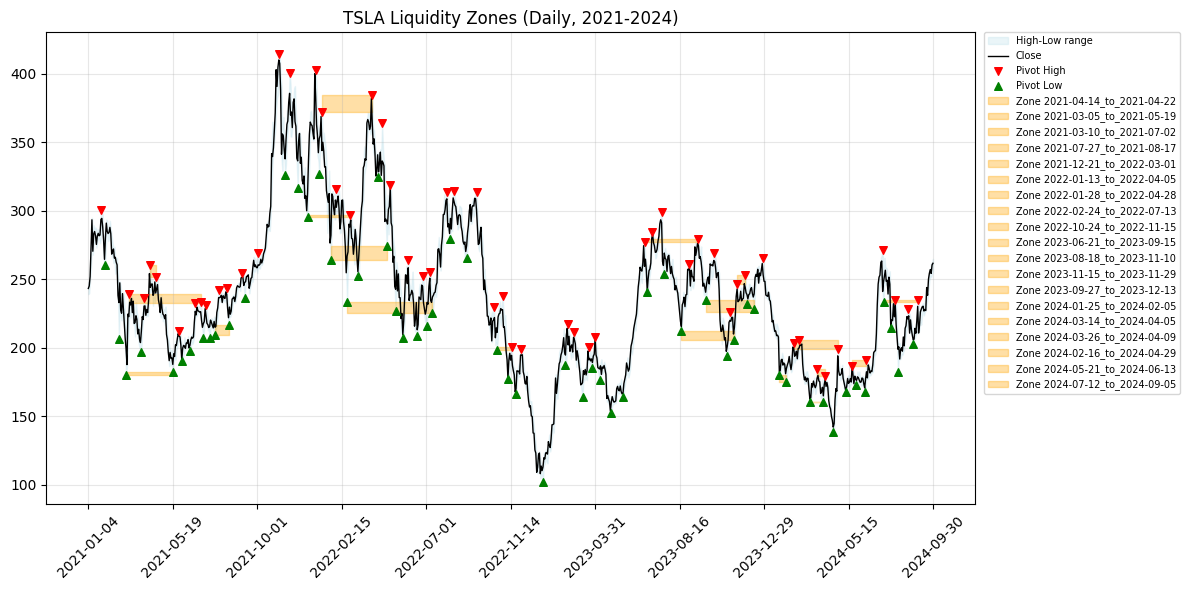

In [16]:
# ---------------------------------------------------------------------------
# Visualize Daily Zones
# ---------------------------------------------------------------------------
plot_zones_matplotlib(
    df_z_daily, zones_df_daily,
    start_date=START_DATE.isoformat(),
    end_date=END_DATE.isoformat(),
    title=f"{TICKER} Liquidity Zones (Daily, {START_DATE.year}-{END_DATE.year})",
    save_dir="charts"
)


## Part 4 — Hourly (LTF) Liquidity Zone Analysis

Repeat zone detection on the **hourly** timeframe. Because the source CSV contains no volume column, `require_volume` is automatically set to `False` and zones are formed purely from price-structure pivots (all pivot highs/lows are treated as equally significant).


In [ ]:
# ---------------------------------------------------------------------------
# Build Liquidity Zones — Hourly (LTF)
# ---------------------------------------------------------------------------
_hourly = reload_hourly.copy()
_hourly.columns = [c.lower() for c in _hourly.columns]

# Normalize common alternative volume column names to 'volume'
_VOL_ALIASES = ["tick_volume", "real_volume", "vol", "qty", "quantity"]
if "volume" not in _hourly.columns:
    for alias in _VOL_ALIASES:
        if alias in _hourly.columns:
            _hourly = _hourly.rename(columns={alias: "volume"})
            print(f"[Info] Renamed '{alias}' -> 'volume'")
            break
    else:
        print("[Warning] No volume column found — volume filtering disabled for hourly data.")

# Ensure required OHLC columns are present with standard names
for col in ["open", "high", "low", "close"]:
    if col not in _hourly.columns:
        raise KeyError(f"Required column '{col}' not found in hourly data. Columns: {_hourly.columns.tolist()}")

print(f"Hourly columns: {_hourly.columns.tolist()}")
print("\n=== Processing Hourly Data ===")
zones_df_hourly, df_z_hourly = build_liquidity_zones(
    _hourly,
    pivot_left_right=5,
    atr_len=14,
    atr_merge_mult=1.0,
    require_volume=("volume" in _hourly.columns),
    vol_len=20,
    vol_mult=1.0,
    min_touches=2,
    unique_pivots=False,
    use_both_high_low_pivots=True,
)
print(f"\n=== Liquidity Zones (confirmed, hourly): {len(zones_df_hourly)} zones ===")
zones_df_hourly.head(10)


[Warning] No volume column found — volume filtering disabled for hourly data.
Hourly columns: ['open', 'high', 'low', 'close', '% change']

=== Processing Hourly Data ===

=== Liquidity Zones (confirmed, hourly): 211 zones ===


,zone_id,top,bottom,height,touches,first_idx,last_idx,first_time,last_time
0,2021-01-11_to_2021-01-11,272.28,267.87,4.41,2,35,41,2021-01-11 14:00:00,2021-01-11 20:00:00
1,2021-01-08_to_2021-01-12,294.80,289.31,5.49,2,30,44,2021-01-08 16:00:00,2021-01-12 16:00:00
2,2021-01-14_to_2021-01-20,287.63,285.82,1.81,2,57,77,2021-01-14 15:00:00,2021-01-20 14:00:00
3,2021-01-25_to_2021-01-26,300.07,297.48,2.59,2,99,109,2021-01-25 15:00:00,2021-01-26 18:00:00
4,2021-01-19_to_2021-02-03,285.30,282.98,2.32,3,70,148,2021-01-19 14:00:00,2021-02-03 15:00:00
5,2021-02-02_to_2021-02-08,293.47,292.41,1.06,2,143,168,2021-02-02 17:00:00,2021-02-08 14:00:00
6,2021-01-13_to_2021-02-11,277.80,276.25,1.55,4,52,189,2021-01-13 17:00:00,2021-02-11 14:00:00
7,2021-01-15_to_2021-02-16,273.02,270.00,3.02,3,69,203,2021-01-15 20:00:00,2021-02-16 14:00:00
8,2021-02-10_to_2021-02-18,266.67,264.88,1.79,3,183,223,2021-02-10 15:00:00,2021-02-18 20:00:00
9,2021-02-17_to_2021-02-24,255.40,247.76,7.64,2,210,251,2021-02-17 14:00:00,2021-02-24 20:00:00


## Part 5 — Liquidity Sweep Detection

A **liquidity sweep** occurs when price briefly spikes through a prior pivot (triggering stop orders resting beyond it) but then closes back inside — indicating a false breakout that absorbed liquidity.

**Detection logic:**

| Sweep type | Condition |
|---|---|
| Buy-side sweep | `high > last_pivot_high + buffer` **and** `close < last_pivot_high` |
| Sell-side sweep | `low < last_pivot_low − buffer` **and** `close > last_pivot_low` |

where `buffer = 0.10 × ATR(14)` to avoid noise.

After detection, each sweep is cross-referenced against the zones built in Parts 3 & 4. Sweeps that fall within `0.25 × ATR` of a zone boundary are flagged with `sweep_near_zone = True` and annotated with the matching `sweep_zone_id`.


In [18]:
# ---------------------------------------------------------------------------
# Detect & Tag Liquidity Sweeps — Daily and Hourly
# ---------------------------------------------------------------------------
sweep_cols = ["buy_side_sweep", "sell_side_sweep", "swept_level", "sweep_near_zone", "sweep_zone_id"]

# Daily (use already-normalized _daily)
sweeps_df_daily = detect_liquidity_sweeps(_daily, left=3, right=3, atr_len=14, buffer_atr=0.10, unique_pivots=True)
sweeps_tagged_daily = tag_sweeps_at_zones(sweeps_df_daily, zones_df_daily, proximity_atr_mult=0.25, max_days_after_zone_end=0)
print("=== Recent Sweeps (daily, last 10 rows) ===")
display(sweeps_tagged_daily[sweep_cols].tail(10))

# Hourly (use already-normalized _hourly)
sweeps_df_hourly = detect_liquidity_sweeps(_hourly, left=3, right=3, atr_len=14, buffer_atr=0.10, unique_pivots=True)
sweeps_tagged_hourly = tag_sweeps_at_zones(sweeps_df_hourly, zones_df_hourly, proximity_atr_mult=0.25, max_days_after_zone_end=0)
print("\n=== Recent Sweeps (hourly, last 10 rows) ===")
display(sweeps_tagged_hourly[sweep_cols].tail(10))


=== Recent Sweeps (daily, last 10 rows) ===


,buy_side_sweep,sell_side_sweep,swept_level,sweep_near_zone,sweep_zone_id
Datetime,,,,,
2024-09-17,False,False,NaN,False,NaN
2024-09-18,False,False,NaN,False,NaN
2024-09-19,False,False,NaN,False,NaN
2024-09-20,False,False,NaN,False,NaN
2024-09-23,False,False,NaN,False,NaN
2024-09-24,False,False,NaN,False,NaN
2024-09-25,False,False,NaN,False,NaN
2024-09-26,False,False,NaN,False,NaN
2024-09-27,False,False,NaN,False,NaN



=== Recent Sweeps (hourly, last 10 rows) ===


,buy_side_sweep,sell_side_sweep,swept_level,sweep_near_zone,sweep_zone_id
Datetime,,,,,
2024-09-27 18:00:00,False,False,NaN,False,NaN
2024-09-27 19:00:00,False,False,NaN,False,NaN
2024-09-27 20:00:00,False,False,NaN,False,NaN
2024-09-30 14:00:00,False,False,NaN,False,NaN
2024-09-30 15:00:00,True,False,261.04,False,NaN
2024-09-30 16:00:00,False,False,NaN,False,NaN
2024-09-30 17:00:00,False,False,NaN,False,NaN
2024-09-30 18:00:00,False,False,NaN,False,NaN
2024-09-30 19:00:00,False,True,256.79,False,NaN


C:\Users\rickc\AppData\Local\Temp\ipykernel_35308\1120650361.py:56: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


Chart saved to charts\TSLA_Liquidity_Zones_(Hourly,_2021-2024).png


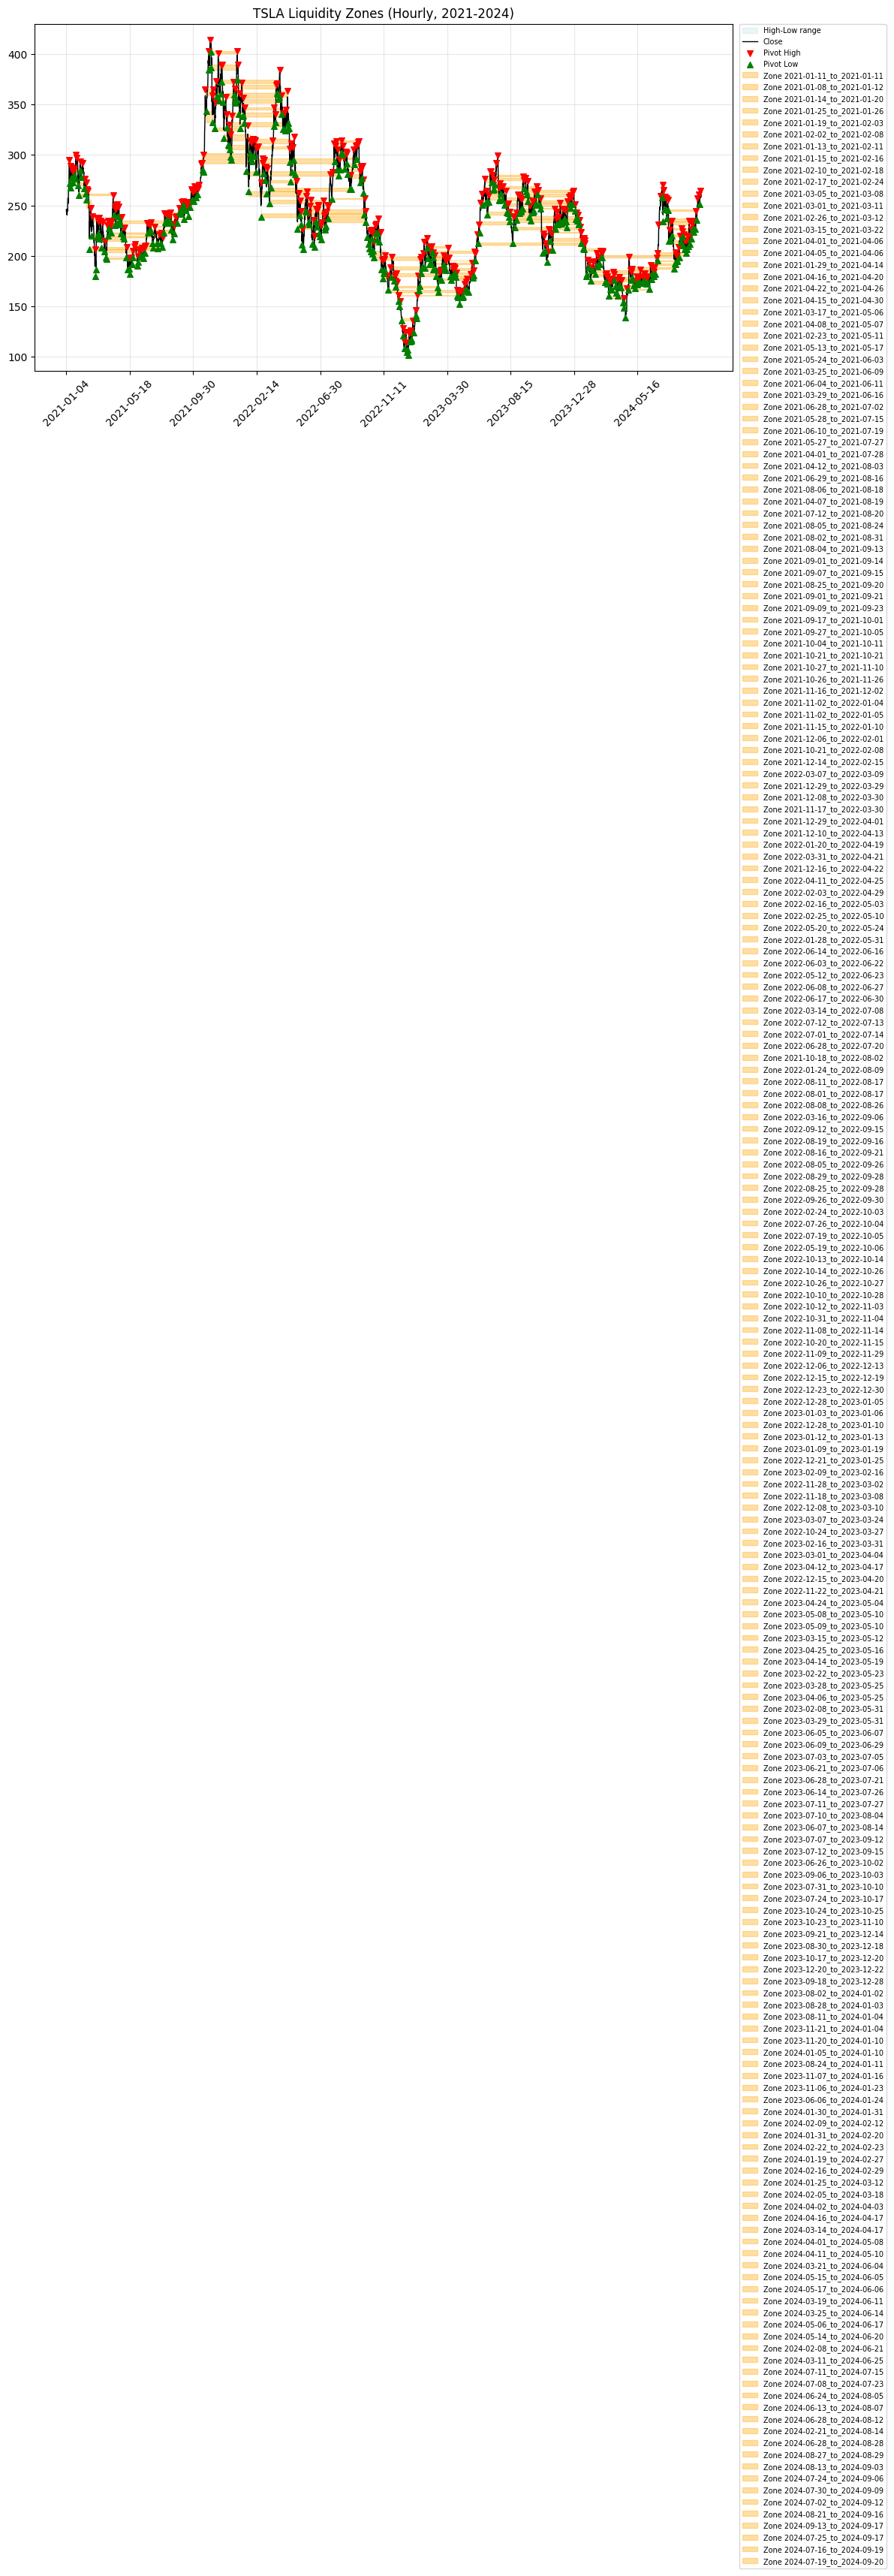

In [19]:
# ---------------------------------------------------------------------------
# Visualize Hourly Zones
# ---------------------------------------------------------------------------
plot_zones_matplotlib(
    df_z_hourly, zones_df_hourly,
    start_date=START_DATE.isoformat(),
    end_date=END_DATE.isoformat(),
    title=f"{TICKER} Liquidity Zones (Hourly, {START_DATE.year}-{END_DATE.year})",
    save_dir="charts"
)


## Part 6 — Export Results to Excel

Save all outputs for both timeframes to separate Excel workbooks in the working directory.

| File | Contents |
|---|---|
| `TSLA_results_daily.xlsx` | All daily-timeframe results |
| `TSLA_results_hourly.xlsx` | All hourly-timeframe results |

Each workbook contains four sheets:

| Sheet | Contents |
|---|---|
| `OHLCV` | Price bars joined with sweep flags and the active zone ID per bar |
| `Liquidity_Zones` | Zone table — top, bottom, height, touch count, and timestamps |
| `Sweeps` | Full sweep-detection output for all bars |
| `Tagged_Sweeps` | Sweeps enriched with zone proximity labels (`sweep_near_zone`, `sweep_zone_id`) |


In [21]:
# ---------------------------------------------------------------------------
# Save Results to Excel — Daily & Hourly
# ---------------------------------------------------------------------------
ohlcv_base_cols = ["open", "high", "low", "close", "volume"]

for label, df_z, zones_df, sweeps_df, sweeps_tagged in [
    ("daily",  df_z_daily,  zones_df_daily,  sweeps_df_daily,  sweeps_tagged_daily),
    ("hourly", df_z_hourly, zones_df_hourly, sweeps_df_hourly, sweeps_tagged_hourly),
]:
    # Only include columns that actually exist in the dataframe
    avail_ohlcv = [c for c in ohlcv_base_cols if c in df_z.columns]
    tag_cols = ["buy_side_sweep", "sell_side_sweep", "swept_level", "sweep_near_zone", "sweep_zone_id"] + avail_ohlcv

    excel_path = f"{TICKER}_results_{label}.xlsx"
    with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
        sweep_cols_basic = sweeps_df[["buy_side_sweep", "sell_side_sweep", "swept_level"]]
        ohlcv_zone = df_z[avail_ohlcv].join(sweep_cols_basic).assign(zone_id=df_z["zone_id"])
        ohlcv_zone.to_excel(writer, index=True, sheet_name="OHLCV")
        zones_df.to_excel(writer, index=False, sheet_name="Liquidity_Zones")
        sweeps_df.to_excel(writer, index=True, sheet_name="Sweeps")
        avail_tag_cols = [c for c in tag_cols if c in sweeps_tagged.columns]
        sweeps_tagged[avail_tag_cols].to_excel(writer, index=True, sheet_name="Tagged_Sweeps")
    print(f"Saved {label} results -> {excel_path}")


Saved daily results -> TSLA_results_daily.xlsx
Saved hourly results -> TSLA_results_hourly.xlsx
